In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

In [16]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()   # convert to Series
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")
print(f"Class distribution in training:\n{y_train.value_counts()}")
print(" Loaded cleaned data (time column already dropped)\n")

Training set shape: (239, 11)
Testing set shape:  (60, 11)
Class distribution in training:
DEATH_EVENT
0    162
1     77
Name: count, dtype: int64
 Loaded cleaned data (time column already dropped)



In [17]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

In [18]:
print("=== Baseline Logistic Regression Results ===\n")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc:.4f}")

=== Baseline Logistic Regression Results ===

Accuracy  : 0.7000
Precision : 0.5385
Recall    : 0.3684
F1-Score  : 0.4375
AUC-ROC   : 0.7445


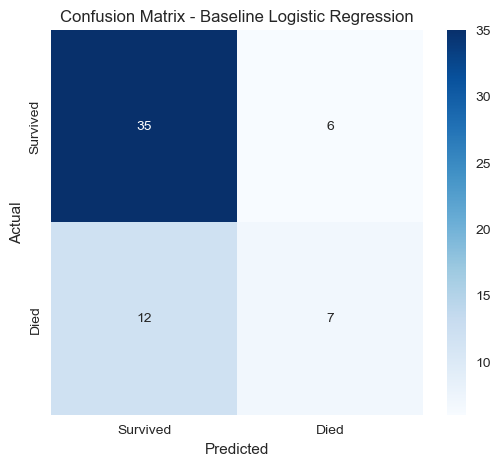

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

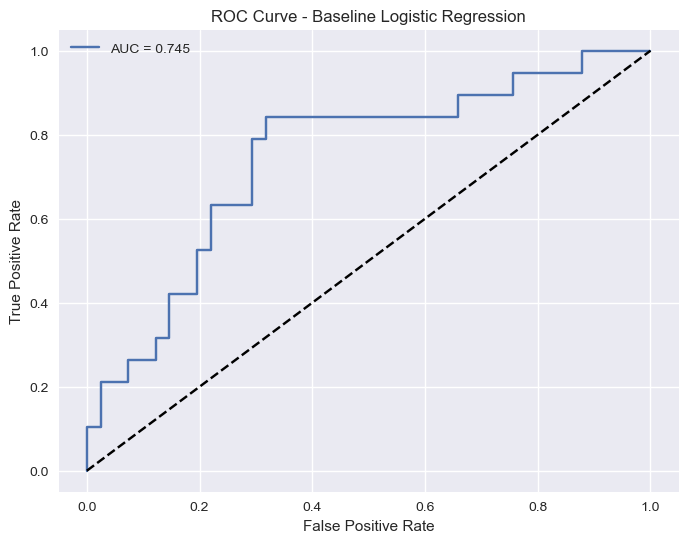

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Logistic Regression')
plt.legend()
plt.show()

In [26]:
print("\n=== Hyperparameter Tuning with GridSearchCV ===\n")

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=2000),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

# Best model
best_log_reg = grid_search.best_estimator_

# Predictions with best model
y_pred_best = best_log_reg.predict(X_test)
y_pred_proba_best = best_log_reg.predict_proba(X_test)[:, 1]


=== Hyperparameter Tuning with GridSearchCV ===

Best Parameters: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation F1 Score: 0.6644



=== Tuned Logistic Regression Results ===

Accuracy  : 0.6667
Precision : 0.4762
Recall    : 0.5263
F1-Score  : 0.5000
AUC-ROC   : 0.7227

Baseline vs Tuned Comparison:


,Metric,Baseline,Tuned
0,Accuracy,0.700000,0.666667
1,Precision,0.538462,0.476190
2,Recall,0.368421,0.526316
3,F1-Score,0.437500,0.500000
4,AUC-ROC,0.744544,0.722721


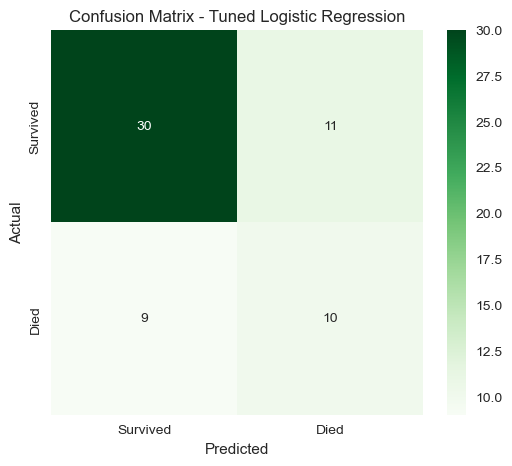

In [27]:
print("\n=== Tuned Logistic Regression Results ===\n")

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_pred_proba_best)

print(f"Accuracy  : {acc_best:.4f}")
print(f"Precision : {prec_best:.4f}")
print(f"Recall    : {rec_best:.4f}")
print(f"F1-Score  : {f1_best:.4f}")
print(f"AUC-ROC   : {auc_best:.4f}")

# Comparison Table
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Baseline': [accuracy, precision, recall, f1, auc],
    'Tuned': [acc_best, prec_best, rec_best, f1_best, auc_best]
})
print("\nBaseline vs Tuned Comparison:")
display(results)

# Final Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

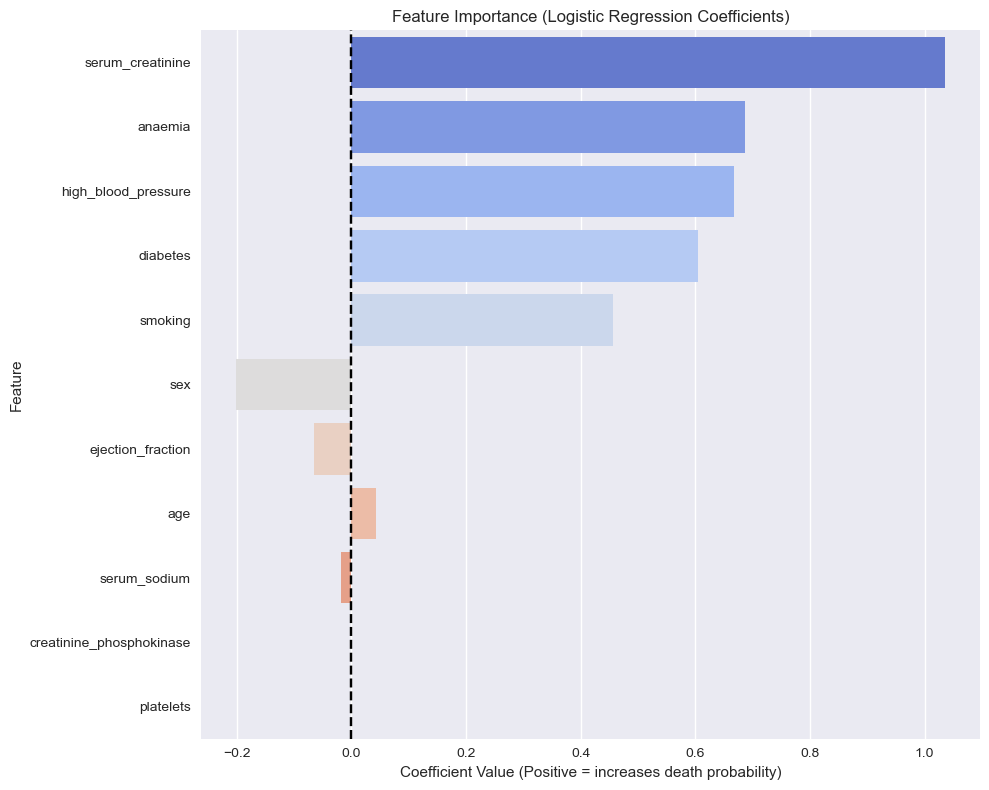


Top 5 Most Important Features (by absolute coefficient):


,Feature,Coefficient
0,serum_creatinine,1.034866
1,anaemia,0.687275
2,high_blood_pressure,0.668345
3,diabetes,0.605394
4,smoking,0.456249


In [28]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_log_reg.coef_[0]
})

# Add absolute value for ranking
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Coefficient Value (Positive = increases death probability)')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features (by absolute coefficient):")
display(coefficients[['Feature', 'Coefficient']].head(5))

In [29]:
cv_scores = cross_val_score(best_log_reg, X_train, y_train, cv=5, scoring='f1')
print(f"\n5-Fold Cross Validation F1 Scores: {cv_scores.round(4)}")
print(f"Mean CV F1 Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")




5-Fold Cross Validation F1 Scores: [0.5882 0.6667 0.7059 0.75   0.6111]
Mean CV F1 Score: 0.6644 ± 0.0595
